In [28]:
import matplotlib.pyplot as plt
import datetime as dt
import pandas as pd
import numpy as np

from pathlib import Path
import soundfile as sf

In [29]:
def plot_audio_seg_spectrogram(audio_features, spec_features):
    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    vmax = spec_features['vmax']
    vmin = spec_features['vmin']
    cmap = spec_features['cmap']
    nfft = spec_features['NFFT']

    plt.figure(figsize=(15, 5))
    plt.rcParams.update({'font.size': 18})
    plt.title(f"Spectrogram", fontsize=24)
    plt.specgram(audio_seg+1e-6, NFFT=nfft, cmap=cmap, vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')
    plt.yticks(ticks=np.linspace(0, 1, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
    plot_xtype = 'float'
    plt.xticks(ticks=np.linspace(0, duration*(fs/2), 11), 
            labels=np.round(np.linspace(start, start+duration, 11, dtype=plot_xtype), 2), rotation=30)
    plt.ylabel("Frequency (kHz)")
    plt.xlabel("Time (s)")
    plt.colorbar()
    plt.show()

In [30]:
HARD_DRIVE_LOC = Path('/Volumes/Elements/UBNA_array_tests2026')

In [31]:
experiment_folder = HARD_DRIVE_LOC / 'recover-20260604'
experiment_folder

PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604')

In [32]:
all_wav_files = list(experiment_folder.glob('STF_*/2026*.WAV'))
all_wav_files

[PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_193756.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_200000.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_203000.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_210000.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_213000.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_220000.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_223000.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_230000.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_233000.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260604_000000.WAV'),
 PosixPath

In [33]:
valid_wav_files = []
for wav_file in all_wav_files:
    wave_file_dt = dt.datetime.strptime(wav_file.name, '%Y%m%d_%H%M%S.WAV')
    if wave_file_dt == dt.datetime(2026, 6, 4, 19, 0, 0):
        valid_wav_files += [wav_file]
valid_wav_files

[PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260604_190000.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_028/20260604_190000.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_025/20260604_190000.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_109/20260604_190000.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_057/20260604_190000.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_114/20260604_190000.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_053/20260604_190000.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_116/20260604_190000.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_030/20260604_190000.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_026/20260604_190000.WAV'),
 PosixPath

In [34]:
SD_CARD_TO_AUDIOMOTH_NUM = {'STF_026': '014', 'STF_028' : '045', 
                            'STF_057': '015', 'STF_109': '008', 
                            'STF_114': '040', 'STF_053': '032', 
                            'STF_021': '016', 'STF_116': '036', 
                            'STF_060': '004', 'STF_025': '042',  
                            'STF_027': '020',
                            'STF_113': '044', 'STF_030': '012'}
SD_CARD_TO_AUDIOMOTH_NUM

{'STF_026': '014',
 'STF_028': '045',
 'STF_057': '015',
 'STF_109': '008',
 'STF_114': '040',
 'STF_053': '032',
 'STF_021': '016',
 'STF_116': '036',
 'STF_060': '004',
 'STF_025': '042',
 'STF_027': '020',
 'STF_113': '044',
 'STF_030': '012'}

In [35]:
AUDIOMOTH_AT_PATCHA = {'014':'A1 (top)', '045':'A1 (bottom)',
                       '015':'A4 (top)', '008':'A4 (bottom)',
                       '040':'A7 (top)', '032':'A7 (bottom)'}
AUDIOMOTH_AT_PATCHE = {'016':'E2 (top)', '036':'E2 (bottom)',
                       '004':'E4 (top)', '042':'E4 (bottom)',
                       '020':'E8 (alone)',
                       '044':'E9 (top)', '012':'E9 (bottom)'}

AUDIOMOTH_AT_ALLPATCHES = AUDIOMOTH_AT_PATCHA | AUDIOMOTH_AT_PATCHE

In [36]:
FREQ_UPPER_LIM = 2/8

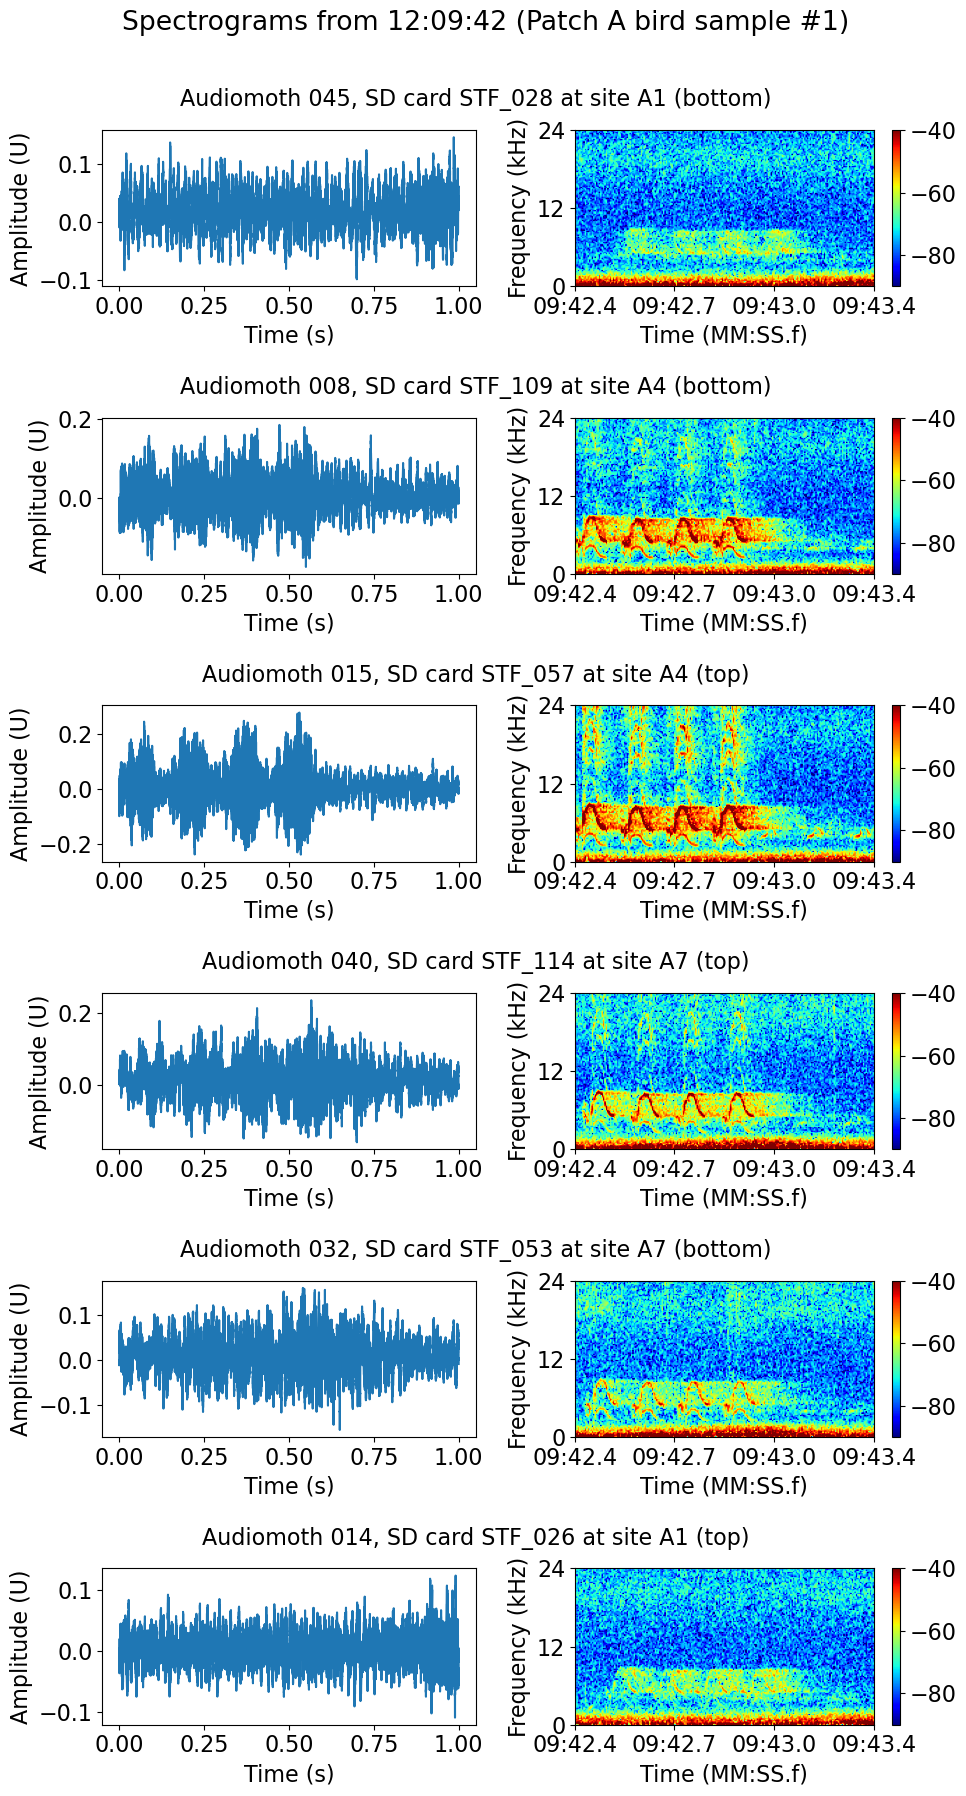

In [37]:
recording_start_dt = dt.datetime(2026, 6, 4, 19, 9, 42, 400000)
recording_start_string = (recording_start_dt - dt.timedelta(hours=7)).strftime('%H:%M:%S')
SAMPLERATE = 192000

fig, ax_all = plt.subplots(len(AUDIOMOTH_AT_PATCHA), 2, figsize=(10, 3*len(AUDIOMOTH_AT_PATCHA)))
plt.rcParams.update({'font.size': 16})
fig.suptitle(f'Spectrograms from {recording_start_string} (Patch A bird sample #1)', y=1.0)

i = 0
for example_wav_file in valid_wav_files:
    wav_SD_card = example_wav_file.parts[-2]
    wav_AUDIOMOTH = SD_CARD_TO_AUDIOMOTH_NUM[wav_SD_card]
    if wav_AUDIOMOTH in AUDIOMOTH_AT_PATCHA.keys():
        example_wav_file_dt = dt.datetime.strptime(example_wav_file.name, '%Y%m%d_%H%M%S.WAV')
        samples_until_recording_start = (recording_start_dt - example_wav_file_dt).total_seconds()
        recorded_audio = sf.SoundFile(example_wav_file)
        read_offset = samples_until_recording_start
        read_duration_in_secs = 1
        recorded_audio.seek(int(SAMPLERATE*read_offset))
        audio_seg = recorded_audio.read(int(SAMPLERATE*read_duration_in_secs))

        vmax = -40
        vmin = -90

        audio_features = dict()
        audio_features['audio_seg'] = audio_seg
        audio_features['sample_rate'] = SAMPLERATE
        audio_features['start'] = read_offset
        audio_features['duration'] = read_duration_in_secs

        spec_features = dict()
        spec_features['NFFT'] = 1024 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
        spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
        spec_features['vmin'] = vmin
        spec_features['vmax'] = vmax

        audio_seg = audio_features['audio_seg']
        fs = audio_features['sample_rate']
        start = audio_features['start']
        duration = audio_features['duration']

        vmax = spec_features['vmax']
        vmin = spec_features['vmin']
        cmap = spec_features['cmap']
        nfft = spec_features['NFFT']

        ax = ax_all[i, 1]
        spec, freqs, t, im = ax.specgram(audio_seg+1e-6, NFFT=nfft, cmap=cmap, vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')
        ax.set_yticks(ticks=np.linspace(0, FREQ_UPPER_LIM, 3), labels=np.linspace(0, FREQ_UPPER_LIM * (fs/2000), 3).astype('int'))
        ax.set_ylim(0, FREQ_UPPER_LIM)
        times = []
        for s in np.linspace(0, duration, 4):
            times += [str(dt.datetime.strftime(recording_start_dt + dt.timedelta(seconds=float(s)), "%M:%S.%f"))[:7]]
        ax.set_xticks(ticks=np.linspace(0, duration*(fs/2), 4), labels=times, rotation=0)
        fig.colorbar(im, ax=ax)
        ax.set_ylabel("Frequency (kHz)")
        ax.set_xlabel("Time (MM:SS.f)") 

        ax = ax_all[i, 0]
        ax.set_title(f"Audiomoth {wav_AUDIOMOTH}, SD card {wav_SD_card} at site {AUDIOMOTH_AT_ALLPATCHES[wav_AUDIOMOTH]}", x=1, y=1.1, fontsize=16)
        ax.plot(np.linspace(0, read_duration_in_secs, read_duration_in_secs*fs), audio_seg)
        ax.set_ylabel('Amplitude (U)')
        ax.set_xlabel("Time (s)") 

        i+=1
fig.tight_layout()
plt.show()

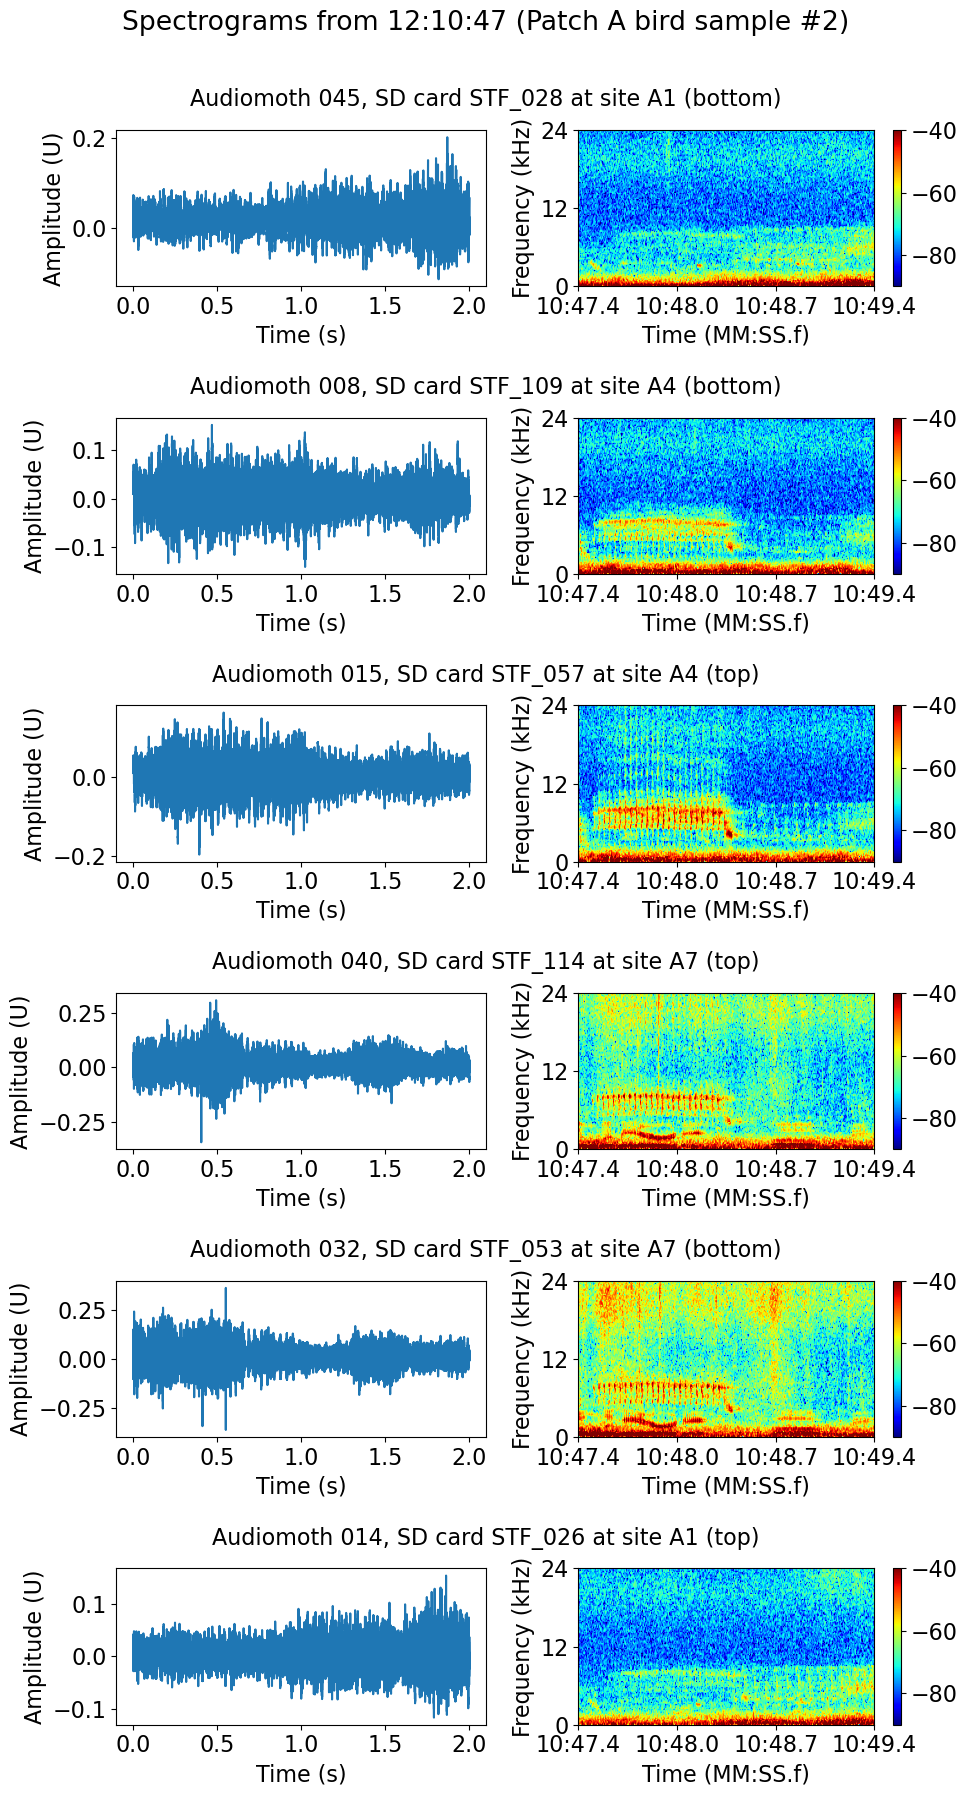

In [38]:
recording_start_dt = dt.datetime(2026, 6, 4, 19, 10, 47, 400000)
recording_start_string = (recording_start_dt - dt.timedelta(hours=7)).strftime('%H:%M:%S')
SAMPLERATE = 192000

fig, ax_all = plt.subplots(len(AUDIOMOTH_AT_PATCHA), 2, figsize=(10, 3*len(AUDIOMOTH_AT_PATCHA)))
plt.rcParams.update({'font.size': 16})
fig.suptitle(f'Spectrograms from {recording_start_string} (Patch A bird sample #2)', y=1.0)

i = 0
for example_wav_file in valid_wav_files:
    wav_SD_card = example_wav_file.parts[-2]
    wav_AUDIOMOTH = SD_CARD_TO_AUDIOMOTH_NUM[wav_SD_card]
    if wav_AUDIOMOTH in AUDIOMOTH_AT_PATCHA.keys():
        example_wav_file_dt = dt.datetime.strptime(example_wav_file.name, '%Y%m%d_%H%M%S.WAV')
        samples_until_recording_start = (recording_start_dt - example_wav_file_dt).total_seconds()
        recorded_audio = sf.SoundFile(example_wav_file)
        read_offset = samples_until_recording_start
        read_duration_in_secs = 2
        recorded_audio.seek(int(SAMPLERATE*read_offset))
        audio_seg = recorded_audio.read(int(SAMPLERATE*read_duration_in_secs))

        vmax = -40
        vmin = -90

        audio_features = dict()
        audio_features['audio_seg'] = audio_seg
        audio_features['sample_rate'] = SAMPLERATE
        audio_features['start'] = read_offset
        audio_features['duration'] = read_duration_in_secs

        spec_features = dict()
        spec_features['NFFT'] = 1024 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
        spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
        spec_features['vmin'] = vmin
        spec_features['vmax'] = vmax

        audio_seg = audio_features['audio_seg']
        fs = audio_features['sample_rate']
        start = audio_features['start']
        duration = audio_features['duration']

        vmax = spec_features['vmax']
        vmin = spec_features['vmin']
        cmap = spec_features['cmap']
        nfft = spec_features['NFFT']

        ax = ax_all[i, 1]
        spec, freqs, t, im = ax.specgram(audio_seg+1e-6, NFFT=nfft, cmap=cmap, vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')
        ax.set_yticks(ticks=np.linspace(0, FREQ_UPPER_LIM, 3), labels=np.linspace(0, FREQ_UPPER_LIM * (fs/2000), 3).astype('int'))
        ax.set_ylim(0, FREQ_UPPER_LIM)
        times = []
        for s in np.linspace(0, duration, 4):
            times += [str(dt.datetime.strftime(recording_start_dt + dt.timedelta(seconds=float(s)), "%M:%S.%f"))[:7]]
        ax.set_xticks(ticks=np.linspace(0, duration*(fs/2), 4), labels=times, rotation=0)
        fig.colorbar(im, ax=ax)
        ax.set_ylabel("Frequency (kHz)")
        ax.set_xlabel("Time (MM:SS.f)") 

        ax = ax_all[i, 0]
        ax.set_title(f"Audiomoth {wav_AUDIOMOTH}, SD card {wav_SD_card} at site {AUDIOMOTH_AT_ALLPATCHES[wav_AUDIOMOTH]}", x=1, y=1.1, fontsize=16)
        ax.plot(np.linspace(0, read_duration_in_secs, read_duration_in_secs*fs), audio_seg)
        ax.set_ylabel('Amplitude (U)')
        ax.set_xlabel("Time (s)") 

        i+=1
fig.tight_layout()
plt.show()

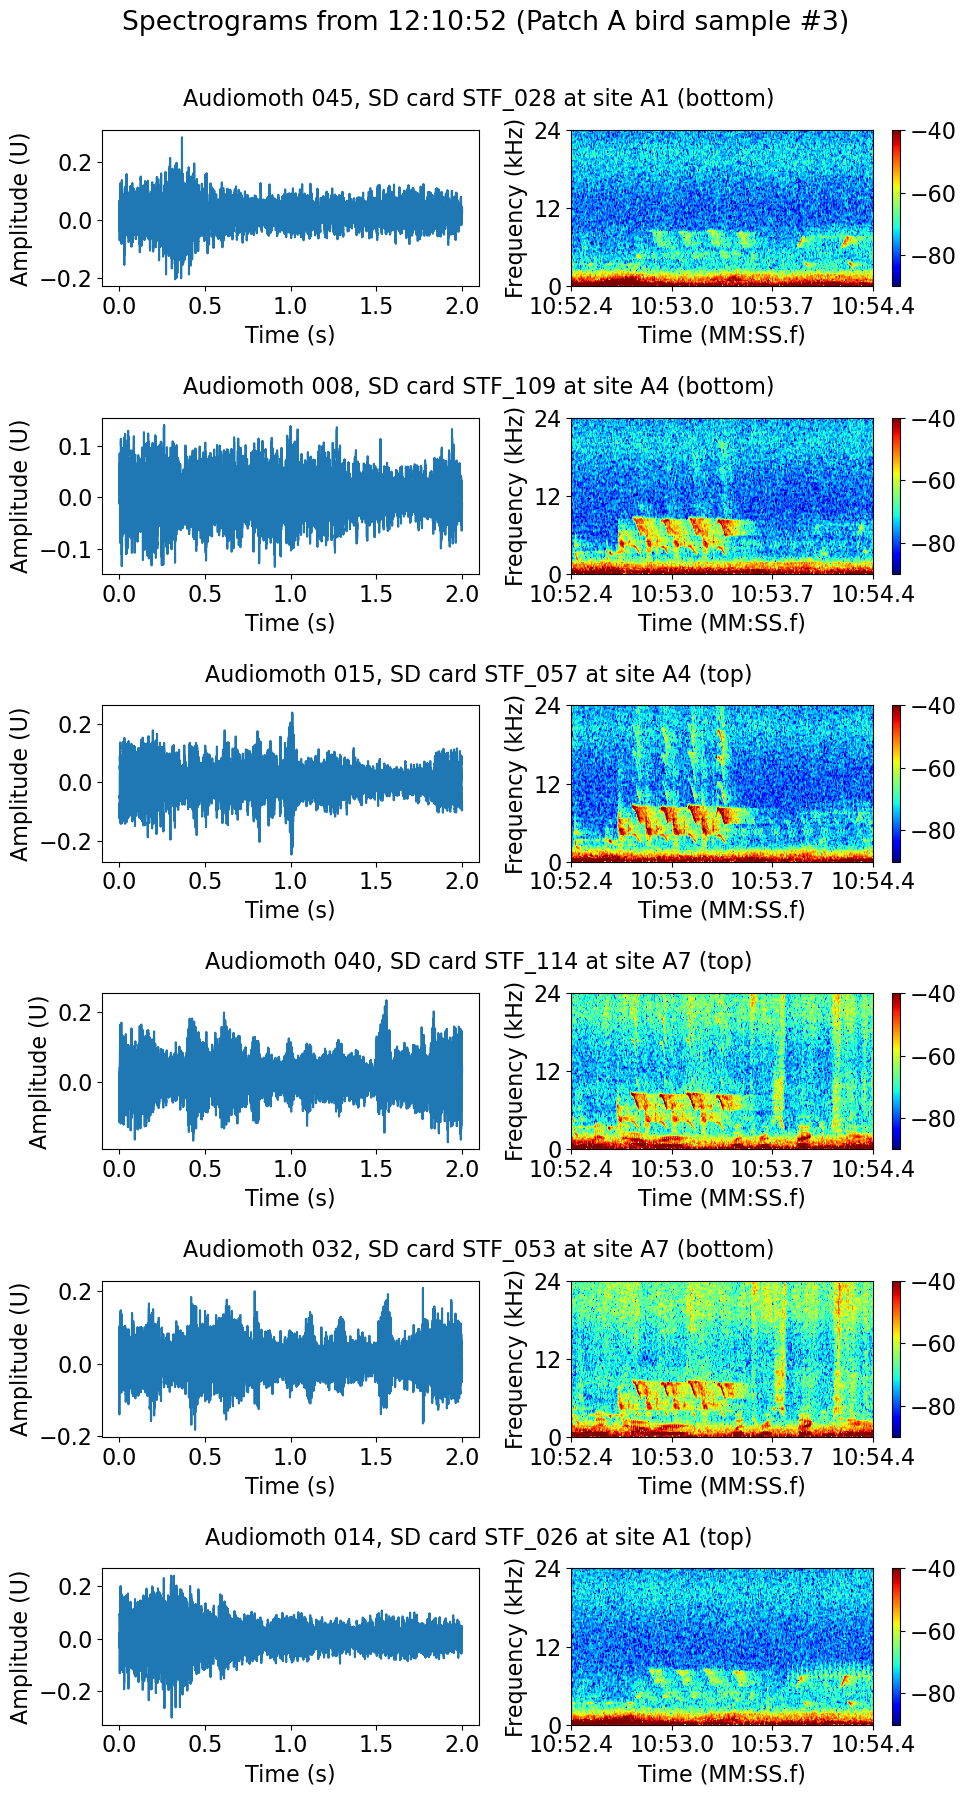

In [39]:
recording_start_dt = dt.datetime(2026, 6, 4, 19, 10, 52, 400000)
recording_start_string = (recording_start_dt - dt.timedelta(hours=7)).strftime('%H:%M:%S')
SAMPLERATE = 192000

fig, ax_all = plt.subplots(len(AUDIOMOTH_AT_PATCHA), 2, figsize=(10, 3*len(AUDIOMOTH_AT_PATCHA)))
plt.rcParams.update({'font.size': 16})
fig.suptitle(f'Spectrograms from {recording_start_string} (Patch A bird sample #3)', y=1.0)

i = 0
for example_wav_file in valid_wav_files:
    wav_SD_card = example_wav_file.parts[-2]
    wav_AUDIOMOTH = SD_CARD_TO_AUDIOMOTH_NUM[wav_SD_card]
    if wav_AUDIOMOTH in AUDIOMOTH_AT_PATCHA.keys():
        example_wav_file_dt = dt.datetime.strptime(example_wav_file.name, '%Y%m%d_%H%M%S.WAV')
        samples_until_recording_start = (recording_start_dt - example_wav_file_dt).total_seconds()
        recorded_audio = sf.SoundFile(example_wav_file)
        read_offset = samples_until_recording_start
        read_duration_in_secs = 2
        recorded_audio.seek(int(SAMPLERATE*read_offset))
        audio_seg = recorded_audio.read(int(SAMPLERATE*read_duration_in_secs))

        vmax = -40
        vmin = -90

        audio_features = dict()
        audio_features['audio_seg'] = audio_seg
        audio_features['sample_rate'] = SAMPLERATE
        audio_features['start'] = read_offset
        audio_features['duration'] = read_duration_in_secs

        spec_features = dict()
        spec_features['NFFT'] = 1024 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
        spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
        spec_features['vmin'] = vmin
        spec_features['vmax'] = vmax

        audio_seg = audio_features['audio_seg']
        fs = audio_features['sample_rate']
        start = audio_features['start']
        duration = audio_features['duration']

        vmax = spec_features['vmax']
        vmin = spec_features['vmin']
        cmap = spec_features['cmap']
        nfft = spec_features['NFFT']

        ax = ax_all[i, 1]
        spec, freqs, t, im = ax.specgram(audio_seg+1e-6, NFFT=nfft, cmap=cmap, vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')
        ax.set_yticks(ticks=np.linspace(0, FREQ_UPPER_LIM, 3), labels=np.linspace(0, FREQ_UPPER_LIM * (fs/2000), 3).astype('int'))
        ax.set_ylim(0, FREQ_UPPER_LIM)
        times = []
        for s in np.linspace(0, duration, 4):
            times += [str(dt.datetime.strftime(recording_start_dt + dt.timedelta(seconds=float(s)), "%M:%S.%f"))[:7]]
        ax.set_xticks(ticks=np.linspace(0, duration*(fs/2), 4), labels=times, rotation=0)
        fig.colorbar(im, ax=ax)
        ax.set_ylabel("Frequency (kHz)")
        ax.set_xlabel("Time (MM:SS.f)") 

        ax = ax_all[i, 0]
        ax.set_title(f"Audiomoth {wav_AUDIOMOTH}, SD card {wav_SD_card} at site {AUDIOMOTH_AT_ALLPATCHES[wav_AUDIOMOTH]}", x=1, y=1.1, fontsize=16)
        ax.plot(np.linspace(0, read_duration_in_secs, read_duration_in_secs*fs), audio_seg)
        ax.set_ylabel('Amplitude (U)')
        ax.set_xlabel("Time (s)") 

        i+=1
fig.tight_layout()
plt.show()